<a href="https://colab.research.google.com/github/nhatlonghuynh/2001222428_HuynhNhatLong/blob/main/LSTM_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
tonleo2863_vietnamese_sentiment_split_path = kagglehub.dataset_download('tonleo2863/vietnamese-sentiment-split')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/valid.csv
/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/train.csv
/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/test.csv


In [ ]:
!pip install underthesea -q

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from underthesea import word_tokenize
import seaborn as sns


# Đọc 3 tập dữ liệu độc lập từ Dataset

In [ ]:
train_df = pd.read_csv('/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/train.csv')
valid_df = pd.read_csv('/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/valid.csv')
test_df = pd.read_csv('/kaggle/input/datasets/tonleo2863/vietnamese-sentiment-split/test.csv')

print(f"Số lượng mẫu ban đầu - Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

Số lượng mẫu ban đầu - Train: 131403, Valid: 28158, Test: 28158


# Tiền xử lý dữ liệu

In [ ]:
def clean_and_segment_text(text):
    text = str(text).lower().strip()
    text = word_tokenize(text,format="text")
    return text

# Làm sạch 3 tập dữ liệu
train_df['text'] = train_df['text'].apply(clean_and_segment_text)
valid_df['text'] = valid_df['text'].apply(clean_and_segment_text)
test_df['text'] = test_df['text'].apply(clean_and_segment_text)

# Loại bỏ dữ liệu thiếu ở cột 'text'
train_df = train_df.dropna(subset=['text'])
valid_df = valid_df.dropna(subset=['text'])
test_df = test_df.dropna(subset=['text'])

# Tách riêng các biến đặc trưng (X) và nhãn dự đoán (Y)
X_train_text, Y_train = train_df['text'], train_df['label']
X_valid_text, Y_valid = valid_df['text'], valid_df['label']
X_test_text, Y_test = test_df['text'], test_df['label']

print("Dữ liệu mẫu sau khi tiền xử lý: ")
print(X_train_text.head())

Dữ liệu mẫu sau khi tiền xử lý: 
0      thằng asus bao đời nay vẫn giữ cái thói này nhỉ
1                                              bánh bt
2    chả qua mẹ chồng dạy sử thôi chứ không t cũng ...
3                      son nó đẳng_cấp thế_giới mẹ rồi
4    đong goi che ten san_pham cửa_hàng chu_đao lam...
Name: text, dtype: object


In [ ]:
train_df['length'] = train_df['text'].apply(lambda x: len(str(x).split()))
train_df['length'].describe()
print(train_df['length'].quantile([0.90, 0.95, 0.99]))

0.90    29.0
0.95    43.0
0.99    91.0
Name: length, dtype: float64


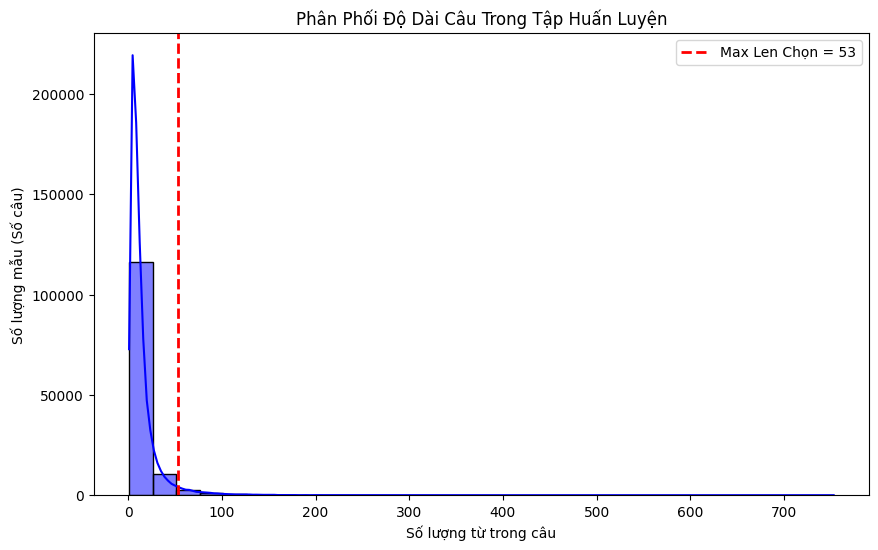

In [ ]:
plt.figure(figsize=(10, 6))
# Vẽ biểu đồ phân phối độ dài từ
sns.histplot(train_df['length'], bins=30, kde=True, color='blue')

chosen_max_len = 53
plt.axvline(x=chosen_max_len, color='red', linestyle='--', linewidth=2, label=f'Max Len Chọn = {chosen_max_len}')

plt.title('Phân Phối Độ Dài Câu Trong Tập Huấn Luyện')
plt.xlabel('Số lượng từ trong câu')
plt.ylabel('Số lượng mẫu (Số câu)')
plt.legend()
plt.show()

# Số hóa văn bản

In [ ]:
max_words = 10000  # Giới hạn từ điển gồm 10,000 từ
max_len = 53       # Độ dài chuẩn của một chuỗi câu

# Khởi tạo Tokenizer và chỉ học từ tập Train
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Chuyển đổi các câu văn bản thành chuỗi số nguyên
train_sequences = tokenizer.texts_to_sequences(X_train_text)
valid_sequences = tokenizer.texts_to_sequences(X_valid_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Cân bằng độ dài câu bằng Padding (Thêm số 0 vào phía sau nếu câu ngắn hơn 53 từ)
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
X_valid = pad_sequences(valid_sequences, maxlen=max_len, padding='post', truncating='post')
X_test  = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Kích thước ma trận sau Padding: Train {X_train.shape}, Valid {X_valid.shape}, Test {X_test.shape}")

Kích thước ma trận sau Padding: Train (131403, 53), Valid (28158, 53), Test (28158, 53)


# Xây dựng và huấn luyện mô hình

In [ ]:
print("So luong mau cua tung nhan trong tap Train:")
print(Y_train.value_counts())

classes = np.unique(Y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=Y_train.values
)
class_weight_dict = dict(zip(classes,weights))

print("\nTrong so toi uu cho tung lop{Class Weight}: ")
for cls, weight in class_weight_dict.items():
    print(f"Nhan {cls}: {weight:.4f}")

So luong mau cua tung nhan trong tap Train:
label
1    46590
2    44087
0    40726
Name: count, dtype: int64

Trong so toi uu cho tung lop{Class Weight}: 
Nhan 0: 1.0755
Nhan 1: 0.9401
Nhan 2: 0.9935


In [ ]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(units=64, dropout=0.3, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')  # Đầu ra 3 lớp
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.build(input_shape=(None, max_len))
model.summary()
history = model.fit(
    X_train, Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=10,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 53, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,587 (5.08 MB)

 Trainable params: 1,331,587 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 50s 46ms/step - accuracy: 0.4553 - loss: 1.0251 - val_accuracy: 0.5829 - val_loss: 0.9006
Epoch 2/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5970 - loss: 0.8469 - val_accuracy: 0.6898 - val_loss: 0.7075
Epoch 3/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - accuracy: 0.7263 - loss: 0.6718 - val_accuracy: 0.7456 - val_loss: 0.6294
Epoch 4/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.7698 - loss: 0.5980 - val_accuracy: 0.7707 - val_loss: 0.5740
Epoch 5/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.7918 - loss: 0.5367 - val_accuracy: 0.7721 - val_loss: 0.5654
Epoch 6/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 46s 45ms/step - accuracy: 0.8048 - loss: 0.5049 - val_accuracy: 0.7792 - val_loss: 0.5504
Epoch 7/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.8136 - loss: 0.4810 - val_accuracy: 0.7818 - val_loss: 0.5423
Epoch 8/10
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.8219 -

# Đánh gái mô hình

In [ ]:
# 1. Kiểm tra độ chính xác (Accuracy) trên tập Test
loss, acc = model.evaluate(X_test, Y_test)
print(f"\n ĐỘ CHÍNH XÁC TRÊN TẬP TEST: {acc * 100:.2f}%\n")

# 2. Dự đoán nhãn cho tập Test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. In báo cáo chi tiết
print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT ===")
print(classification_report(Y_test, y_pred))

# 4. In ma trận nhầm lẫn
print("=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===")
print(confusion_matrix(Y_test, y_pred))

880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7797 - loss: 0.5433

 ĐỘ CHÍNH XÁC TRÊN TẬP TEST: 77.97%

880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
=== BÁO CÁO PHÂN LOẠI CHI TIẾT ===
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      8727
           1       0.73      0.73      0.73      9984
           2       0.82      0.82      0.82      9447

    accuracy                           0.78     28158
   macro avg       0.78      0.78      0.78     28158
weighted avg       0.78      0.78      0.78     28158

=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===
[[6969 1423  335]
 [1330 7255 1399]
 [ 452 1263 7732]]


# Đồ thị trực quan hóa

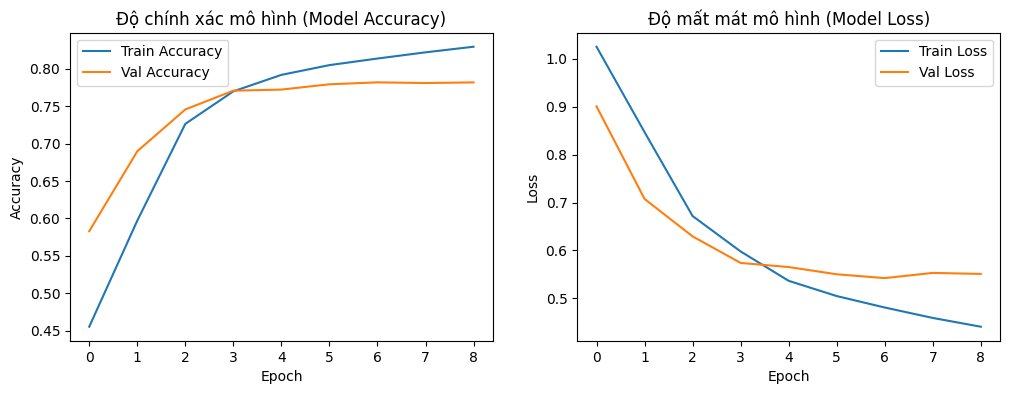

In [ ]:
# Đồ thị hiển thị độ chính xác qua từng Epoch
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Độ chính xác mô hình (Model Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Đồ thị hiển thị độ mất mát qua từng Epoch
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Độ mất mát mô hình (Model Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
def predict_new_comment(text):
    cleaned = clean_and_segment_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred_prob = model.predict(padded, verbose=0)
    pred_label = np.argmax(pred_prob, axis=1)[0]
    label_mapping = {0: "Tiêu cực (Negative)", 1: "Trung tính (Neutral)", 2: "Tích cực (Positive)"}
    print(f"Câu nhập vào: {text}")
    print(f"Mô hình dự đoán: {label_mapping[pred_label]} (Xác suất: {pred_prob[0][pred_label]*100:.2f}%)")
predict_new_comment("ngay hom nay that dep")

Câu nhập vào: ngay hom nay that dep
Mô hình dự đoán: Tích cực (Positive) (Xác suất: 69.87%)
